In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
# Chargement du fichier local
df = pd.read_csv("monthly-robberies.csv", index_col=0, parse_dates=True)

# Affichage des premières lignes pour vérification visuelle
print("Aperçu des données :")
print(df.head())
print("\nInformations structurelles :")
print(df.info())

# Vérification de la fréquence détectée
print(f"Fréquence actuelle : {df.index.freq}")

# Forcer la fréquence à 'MS' (Month Start) si elle n'est pas détectée
df.index.freq = 'MS'
print(f"Fréquence après correction : {df.index.freq}")

Aperçu des données :
            Robberies
Month                
1966-01-01         41
1966-02-01         39
1966-03-01         50
1966-04-01         40
1966-05-01         43

Informations structurelles :
<class 'pandas.DataFrame'>
DatetimeIndex: 118 entries, 1966-01-01 to 1975-10-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Robberies  118 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB
None


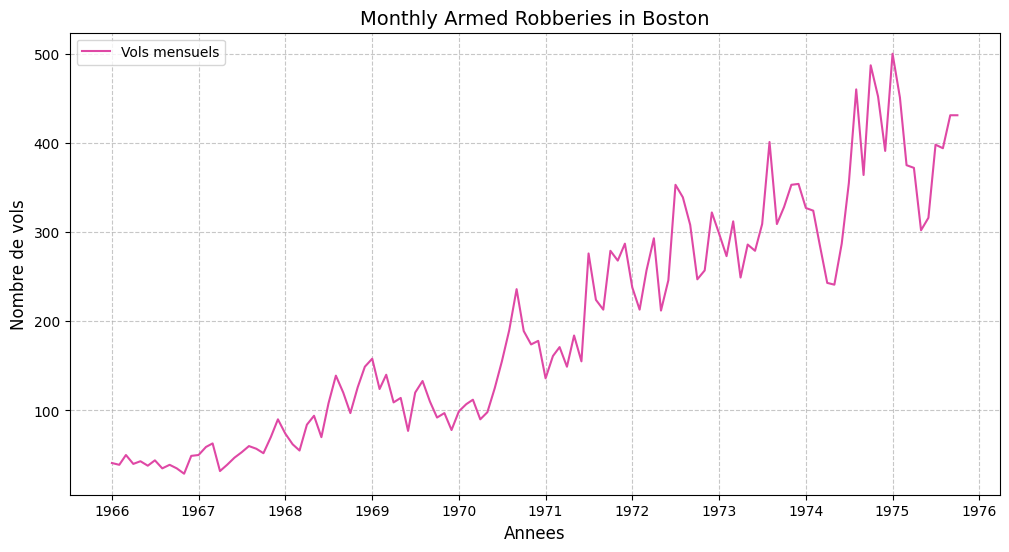

In [22]:
# Définir la taille de la figure
plt.figure(figsize=(12, 6))

plt.plot(df.index, df['Robberies'], color="#df48a5",  label='Vols mensuels')

# Ajouter les éléments de compréhension
plt.title('Monthly Armed Robberies in Boston', fontsize=14)
plt.xlabel('Annees', fontsize=12)
plt.ylabel('Nombre de vols', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Afficher le graphique
plt.show()

In [6]:
# Calcul de la moyenne
moyenne = df['Robberies'].mean()

# Calcul de la variance
variance = df['Robberies'].var()

# Calcul de l'écart-type
ecart_type = df['Robberies'].std()


print(f"Moyenne : {moyenne:.2f}") 
print(f"Variance : {variance:.2f}") 
print(f"Écart-type : {ecart_type:.2f}")

print("\nRésumé complet :")
print(df.describe())


Moyenne : 196.29
Variance : 16395.16
Écart-type : 128.04

Résumé complet :
        Robberies
count  118.000000
mean   196.288136
std    128.043602
min     29.000000
25%     85.500000
50%    166.000000
75%    296.750000
max    500.000000


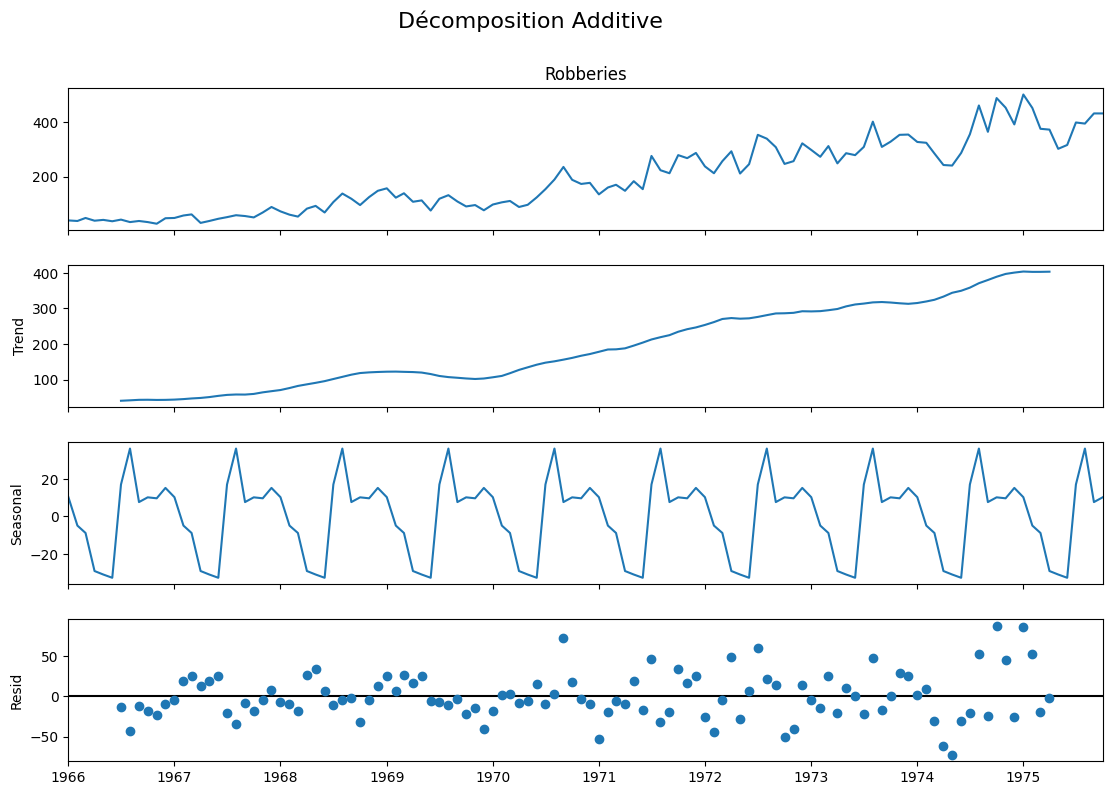

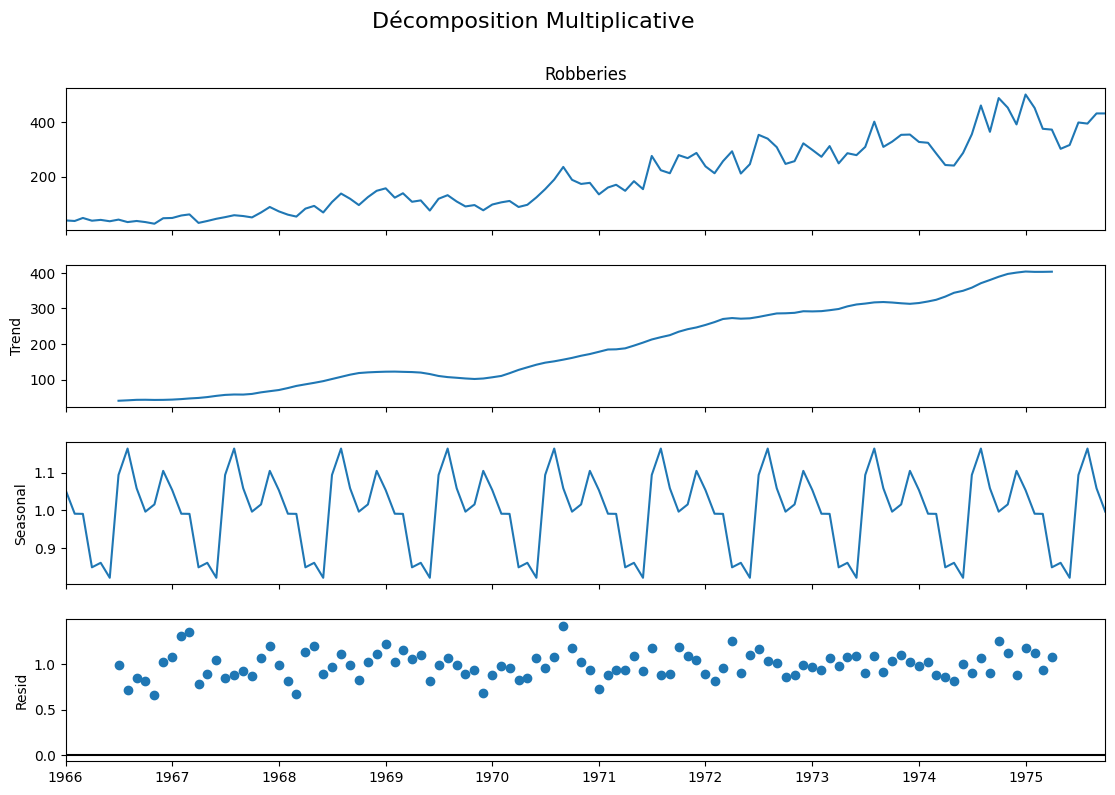

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. Décomposition Additive
add_decomp = seasonal_decompose(df['Robberies'], model='additive', period=12)

# Affichage du modèle additif
fig1 = add_decomp.plot()
fig1.set_size_inches(12, 8) # Taille plus adaptée pour la visibilité
plt.suptitle('Décomposition Additive', fontsize=16, y=1.02) # y=1.02 remonte le titre
plt.show()

# 2. Décomposition Multiplicative
mult_decomp = seasonal_decompose(df['Robberies'], model='multiplicative', period=12)

# Affichage du modèle multiplicatif
fig2 = mult_decomp.plot()
fig2.set_size_inches(12, 8)
plt.suptitle('Décomposition Multiplicative', fontsize=16, y=1.02)
plt.show()

ADF:
p_value=0.994277563805723,la serie n'est pas stationnaire :on accepte H0
KPSS:
p_value=0.01,la serie n'est pas stationnaire :on refuse H0
----------------------------------------
stationnarite pour la serie transformee:
p_value=6.450795412686658e-11,la serie est stationnaire :on rejette H0


/var/folders/lb/cgj614px3bzbrncdwk2l9lp80000gq/T/ipykernel_6045/4265265745.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result= kpss(series, regression='c')


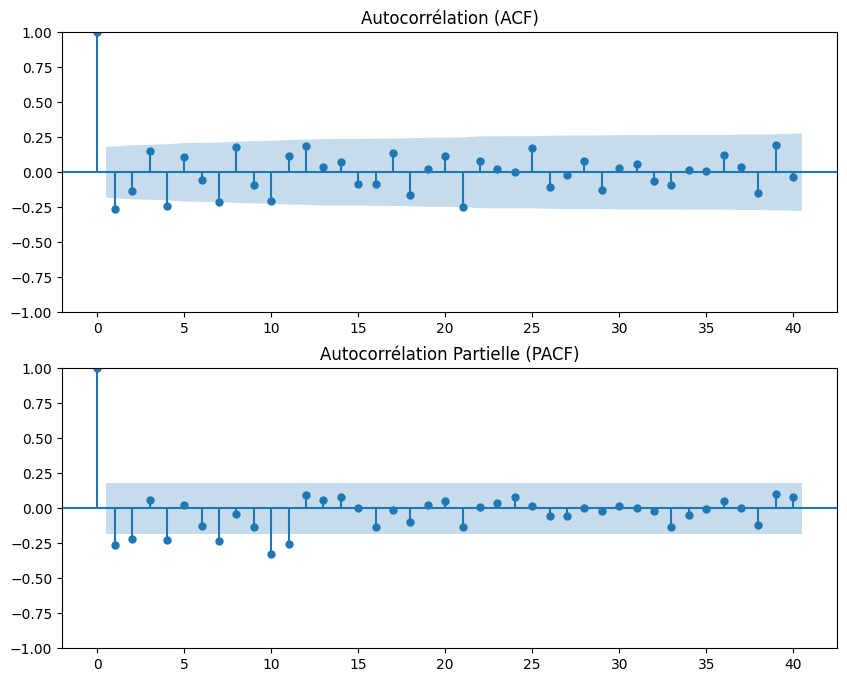

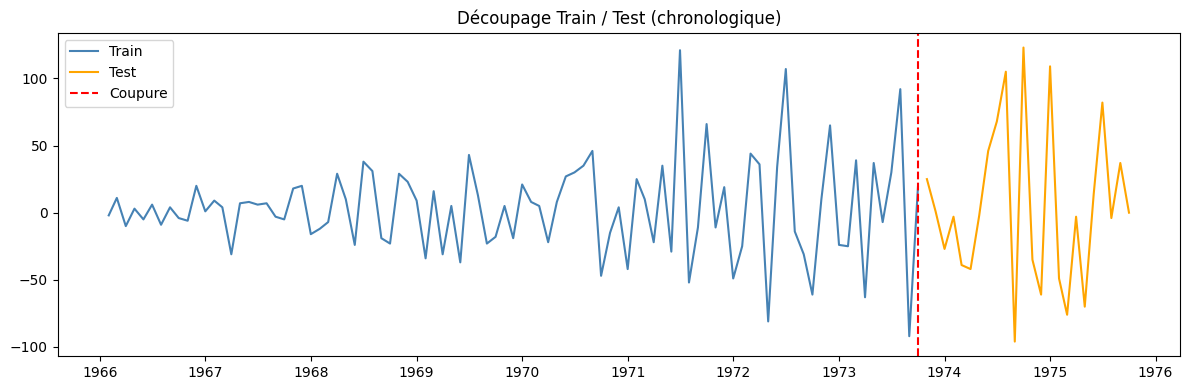

In [8]:
from pandas import read_csv
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series=read_csv(r"monthly-robberies.csv",header=0,index_col=0, parse_dates=True).squeeze()

#test ADF
def adf_test(serie):
    result=adfuller(serie)
    p_value=result[1]
    if p_value <0.05:
        print(f"p_value={p_value},la serie est stationnaire :on rejette H0")
    else:
        print(f"p_value={p_value},la serie n'est pas stationnaire :on accepte H0")

print("ADF:") 
adf_test(series)
#test kpss
def kpss_test():
    result= kpss(series, regression='c') 
    p_value=result[1]
    if p_value >0.05:
        print(f"p_value={p_value},la serie est stationnaire :on accepte H0")
    else:
        print(f"p_value={p_value},la serie n'est pas stationnaire :on refuse H0")

print("KPSS:")
kpss_test()

#power transformers
series_sqrt=np.sqrt(series)

series_log = np.log(series)
# plt.figure(1)
# plt.plot(series)
# plt.title("serie originale")
# plt.figure(2)
# plt.plot(series_log)
# plt.title("serie transformee")
# plt.show()

#differenciation

series_diff = series_log.diff()
series_diff = series.diff().dropna()
# plt.figure()
# plt.plot(series_diff)
# plt.title("serie diferenciee")
# plt.show()

#stationnarite apres transformation
print("----------------------------------------")
print("stationnarite pour la serie transformee:")
adf_test(series_diff)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Tracé de l'ACF
plot_acf(series_diff, ax=ax1, lags=40, title="Autocorrélation (ACF)")
# Tracé de la PACF
plot_pacf(series_diff, ax=ax2, lags=40, title="Autocorrélation Partielle (PACF)")
plt.show()

#decoupage de la serie
n = len(series_diff)
split_ratio = 0.8                        # 80% train, 20% test

split_index = int(n * split_ratio)

train = series_diff[:split_index]
test  =series_diff[split_index:]

# visualisation
plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label="Train", color="steelblue")
plt.plot(test.index,  test,  label="Test",  color="orange")
plt.axvline(x=train.index[-1], color="red", linestyle="--", label="Coupure")
plt.title("Découpage Train / Test (chronologique)")
plt.legend()
plt.tight_layout()
plt.show()

=== Modèle Naïf ===
RMSE = 59.505
MAE = 46.542

=== Modèle Moyenne Mobile (k=12) ===
RMSE = 73.197
MAE = 56.851


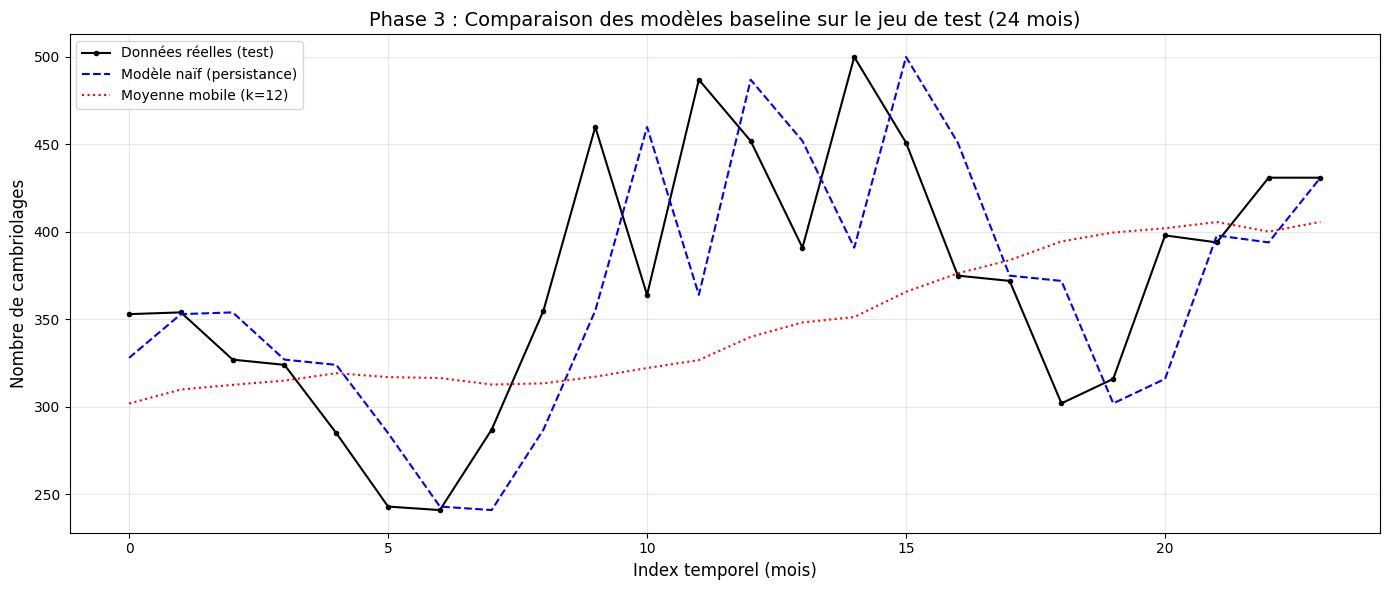

In [12]:


data = pd.read_csv('monthly-robberies.csv', header=0, index_col=0, parse_dates=True)

values = data['Robberies'].values.astype('float32')

train_size = int(len(values) * 0.8)
train, test = values[:train_size], values[train_size:]

# --- Fonctions Métriques (from scratch) ---
def mse(y_true, y_pred): return np.mean((y_true - y_pred)**2)
def rmse(y_true, y_pred): return np.sqrt(mse(y_true, y_pred))
def mae(y_true, y_pred): return np.mean(np.abs(y_true - y_pred))

# --- Walk-Forward Validation : Naïf ---
history = list(train)
predictions_naive = []
for obs in test:
    yhat = history[-1]
    predictions_naive.append(yhat)
    history.append(obs)

# --- Walk-Forward Validation : Moyenne Mobile (k=12) ---
history = list(train)
predictions_ma = []
window = 12
for obs in test:
    yhat = np.mean(history[-window:])
    predictions_ma.append(yhat)
    history.append(obs)

# --- Affichage des Résultats ---
print(f"=== Modèle Naïf ===\nRMSE = {rmse(test, predictions_naive):.3f}\nMAE = {mae(test, predictions_naive):.3f}")
print(f"\n=== Modèle Moyenne Mobile (k={window}) ===\nRMSE = {rmse(test, predictions_ma):.3f}\nMAE = {mae(test, predictions_ma):.3f}")

# --- GÉNÉRATION DU GRAPHIQUE  ---
plt.figure(figsize=(14, 6))
plt.plot(test, label='Données réelles (test)', color='black', linewidth=1.5, marker='o', markersize=3)
plt.plot(predictions_naive, label='Modèle naïf (persistance)', color='blue', linestyle='--', linewidth=1.5)
plt.plot(predictions_ma, label=f'Moyenne mobile (k={window})', color='red', linestyle=':', linewidth=1.5)

plt.title('Phase 3 : Comparaison des modèles baseline sur le jeu de test (24 mois)', fontsize=14)
plt.xlabel('Index temporel (mois)', fontsize=12)
plt.ylabel('Nombre de cambriolages', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

 
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd
from scipy.linalg import toeplitz
from statsmodels.tsa.stattools import acovf
from statsmodels.tsa.ar_model import AutoReg

def estimate_ar_p_from_scratch(data, p):
    """
    AR(p) From Scratch : Matrice de design + OLS + Yule-Walker
    """
    n = len(data)
    
    # --- 1. CONSTRUCTION DE LA MATRICE DE DESIGN (Pour OLS) ---
    Y = data[p:]
    X = np.ones((n - p, p + 1)) # Colonne de 1 pour l'intercept
    for j in range(1, p + 1):
        X[:, j] = data[p-j : n-j] # Remplissage des lags
        
    # --- 2. ESTIMATION PAR OLS ---
    # Formule matricielle : (X'X)^-1 * X'Y
    beta_ols = np.linalg.inv(X.T @ X) @ X.T @ Y
    intercept_ols = beta_ols[0]
    phi_ols = beta_ols[1:]
    
    # --- 3. ESTIMATION PAR YULE-WALKER ---
    gamma = acovf(data, nlag=p)
    R = toeplitz(gamma[:p])
    r = gamma[1:p+1]
    phi_yw = np.linalg.solve(R, r)
    
    return {
        "OLS": {"intercept": intercept_ols, "phi": phi_ols},
        "Yule-Walker": {"phi": phi_yw}
    }

# --- APPLICATION SUR TES DONNÉES ---
# On utilise 'train' qui est ta série stationnaire de la Phase 2
p_order = 2 

# On utilise .values pour convertir la série pandas en tableau numpy
res = estimate_ar_p_from_scratch(train, p_order)
# --- AFFICHAGE DES RÉSULTATS ---
print("--- RÉSULTATS AR(2) FROM SCRATCH ---")
print(f"OLS - Intercept (c): {res['OLS']['intercept']:.4f}")
print(f"OLS - Coefficients Phi: {res['OLS']['phi']}")
print(f"Yule-Walker - Coefficients Phi: {res['Yule-Walker']['phi']}")

# --- COMPARAISON AVEC STATSMODELS (Pour ton rapport) ---
model_sm = AutoReg(train, lags=p_order).fit()
print("\n--- COMPARAISON STATSMODELS ---")
print(f"SM - Intercept: {model_sm.params[0]:.4f}")
print(f"SM - Coefficients: {model_sm.params[1:]}")

--- RÉSULTATS AR(2) FROM SCRATCH ---
OLS - Intercept (c): 9.5090
OLS - Coefficients Phi: [0.70755056 0.25522413]
Yule-Walker - Coefficients Phi: [0.75111504 0.17575531]

--- COMPARAISON STATSMODELS ---
SM - Intercept: 9.5090
SM - Coefficients: [0.70755056 0.25522413]


In [ ]:
from scipy.optimize import minimize

def ma_objective_function(theta_param, data):
    """
    Calcule la somme des carrés des résidus pour un MA(1)
    """
    # CRITIQUE : theta_param arrive sous forme de tableau [valeur]
    # On extrait la valeur numérique pour éviter l'erreur
    theta = theta_param[0]
    
    mu = np.mean(data)
    n = len(data)
    residus = np.zeros(n)
    
    # Calcul récursif des erreurs
    for t in range(1, n):
        # Maintenant theta est un scalaire, le calcul fonctionne
        residus[t] = data[t] - mu - theta * residus[t-1]
        
    return np.sum(residus**2)

# --- ESTIMATION NUMÉRIQUE ---
initial_theta = [0.1] # Valeur de départ

# On utilise 'train' (ta variable de la Phase 2)
# Assure-toi que 'train' est un tableau numpy sans NaN
result_ma = minimize(ma_objective_function, initial_theta, args=(train,))

theta_scratch = result_ma.x[0]

print(f"MA(1) From Scratch - Theta : {theta_scratch:.4f}")

# --- VÉRIFICATION AVEC STATSMODELS ---
from statsmodels.tsa.arima.model import ARIMA
# Le modèle ARIMA(0,0,1) correspond à un MA(1)
model_ma_sm = ARIMA(train, order=(0, 0, 1)).fit()
print(f"Statsmodels - Theta : {model_ma_sm.params[1]:.4f}")

MA(1) From Scratch - Theta : 0.8012
Statsmodels - Theta : 0.8186


In [19]:


def arma_objective_function(params, data):
    """
    Fonction objectif pour ARMA(1,1)
    params[0] : c (intercept)
    params[1] : phi (paramètre AR)
    params[2] : theta (paramètre MA)
    """
    c = params[0]
    phi = params[1]
    theta = params[2]
    
    n = len(data)
    residus = np.zeros(n)
    
    # Calcul récursif combiné
    # y_t_pred = c + phi * y_{t-1} + theta * epsilon_{t-1}
    # epsilon_t = y_t - y_t_pred
    for t in range(1, n):
        prediction = c + phi * data[t-1] + theta * residus[t-1]
        residus[t] = data[t] - prediction
        
    return np.sum(residus**2)

# --- ESTIMATION ---
# Valeurs de départ : [Intercept, Phi, Theta]
initial_params = [np.mean(train), 0.5, 0.1]

# Optimisation
result_arma = minimize(arma_objective_function, initial_params, args=(train,))

c_fs, phi_fs, theta_fs = result_arma.x

print("--- RÉSULTATS ARMA(1,1) FROM SCRATCH ---")
print(f"Intercept (c) : {c_fs:.4f}")
print(f"Phi (AR1)     : {phi_fs:.4f}")
print(f"Theta (MA1)   : {theta_fs:.4f}")

# --- COMPARAISON STATSMODELS ---
from statsmodels.tsa.arima.model import ARIMA
model_sm = ARIMA(train, order=(1, 0, 1)).fit()
print("\n--- COMPARAISON STATSMODELS ---")
print(f"SM - Intercept: {model_sm.params[0]:.4f}")
print(f"SM - Phi (AR1): {model_sm.params[1]:.4f}")
print(f"SM - Theta (MA1): {model_sm.params[2]:.4f}")

--- RÉSULTATS ARMA(1,1) FROM SCRATCH ---
Intercept (c) : 2.5129
Phi (AR1)     : 1.0043
Theta (MA1)   : -0.6264

--- COMPARAISON STATSMODELS ---
SM - Intercept: 151.8562
SM - Phi (AR1): 0.9908
SM - Theta (MA1): -0.4761


In [20]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# 1. Ajustement du modèle avec Statsmodels
# L'ordre (1, 0, 1) signifie AR=1, Diff=0, MA=1
model_sm = ARIMA(train, order=(1, 0, 1)).fit()

# 2. Extraction des paramètres
params_sm = {
    "Intercept": model_sm.params[0],
    "Phi (AR1)": model_sm.params[1],
    "Theta (MA1)": model_sm.params[2]
}

params_fs = {
    "Intercept": c_fs,
    "Phi (AR1)": phi_fs,
    "Theta (MA1)": theta_fs
}

# 3. Création d'un tableau comparatif
df_comp = pd.DataFrame([params_fs, params_sm], index=["From Scratch", "Statsmodels"])
print("--- TABLEAU COMPARATIF DES PARAMÈTRES ---")
print(df_comp.round(4))

--- TABLEAU COMPARATIF DES PARAMÈTRES ---
              Intercept  Phi (AR1)  Theta (MA1)
From Scratch     2.5129     1.0043      -0.6264
Statsmodels    151.8562     0.9908      -0.4761
